In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 1
T2 = .5

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N)

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

list_of_cnots = [cnot3, cnot4, cnot5, cnot6]

z_gate = qt.Qobj([[1, 0],[0, -1]])

hadamard = 1 / np.sqrt(2) * qt.Qobj([[1, 1],[1, -1]])
hada_layer = tensor(tensor([hadamard] * 3), tensor([qt.qeye(dim)] * 2)) # this does build the appropriate layer for the hadamard encoding and decoding in the circuit 

# creating the new set of cnots 
for i in range(len(list_of_cnots)):
    list_of_cnots[i] = hada_layer * list_of_cnots[i] * hada_layer.dag()

C:\Users\girgi\AppData\Local\Temp\ipykernel_4976\993952201.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_4976\993952201.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_4976\993952201.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from 

In [4]:
# create fidelity function
# add others if you want another metric 
def hilbert_schmidt_fid_func(rho, sigma):
    return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

In [5]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = hada_layer * cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag() * hada_layer.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation
# rho_encoded is represented in the 0,1 basis 

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [ 0.125 -0.125 -0.125  0.125 -0.125  0.125  0.125 -0.125]
 [-0.125  0.125  0.125 -0.125  0.125 -0.125 -0.125  0.125]]

In [6]:
# layers of execution 
# creating the circuit layers 
circuit_layers = [hada_layer, cnot3, cnot4, cnot5, cnot6, hada_layer]

In [7]:
states = []
states.append(rho_encoded)
plotting_states = []


duration_delay = .4
delay_states = trotter.apply(rho=rho_encoded, duration=duration_delay, unitary=tensor([qt.qeye(dim)] * N))
states.extend(delay_states)
plotting_states.extend(hada_layer * delay_states * hada_layer.dag())
rho_encoded = delay_states[-1]

for i in range(len(circuit_layers)):
    rho_evo = circuit_layers[i] * rho_encoded * circuit_layers[i].dag()
    states.append(rho_evo)
    if i not in [len(circuit_layers) - 1]:
        plotting_states.append(rho_evo)
    else:
        plotting_states.append(hada_layer * rho_evo * hada_layer.dag())
    rho_encoded = rho_evo


In [8]:
#### side notes ####
# the patterns that develop when changing the values of t1 and t2 make sense for the population of the states 
# confirmed with the observed pattern in the qubit bit flip experiment 

In [9]:
qt.ptrace(hada_layer * states[-1] * hada_layer.dag(), [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[1.07263876e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 5.63507144e-05]
 [0.00000000e+00 2.15293634e-03 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 5.63507144e-05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.15293634e-03 0.00000000e+00
  0.00000000e+00 5.63507144e-05 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 4.31563930e-02
  5.63507144e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 5.63507144e-05
  2.15293634e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.63507144e-05 0.00000000e+00
  0.00000000e+00 4.31563930e-02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 5.63507144e-05 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.31563930e-02 0.00000000e+00]
 [5.63507144e-05 0.0000

In [10]:
qt.ptrace(hada_layer * states[-1] * hada_layer.dag(), [3,4])

Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.86407201 0.         0.         0.        ]
 [0.         0.04530933 0.         0.        ]
 [0.         0.         0.04530933 0.        ]
 [0.         0.         0.         0.04530933]]

In [11]:
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), z_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(z_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), z_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
recovery = [recovery_ops[i] * density_outcomes[i] * recovery_ops[i].dag() for i in range(len(density_outcomes))]

total_state = []
for i in range(len(recovery)):
    total_state.append(outcomes[i] * recovery[i]) 


total_state_normal = sum(total_state) / (sum(total_state)).tr()
states.append(total_state_normal)
plotting_states.append(hada_layer * total_state_normal * hada_layer.dag())
# fids.append(hilbert_schmidt_fid_func(qt.ptrace(total_state_normal, [0,1,2]), rho_encoded_traced))

total_time = duration_delay 

[0.8640720120749695, 0.04530932930834308, 0.045309329308343305, 0.04530932930834322]


In [12]:
errors = sum(outcomes[1:4])
errors

0.1359279879250296

[0.006566072902159879, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9934339270978398]


Text(0.5, 0, 'time (dt)')

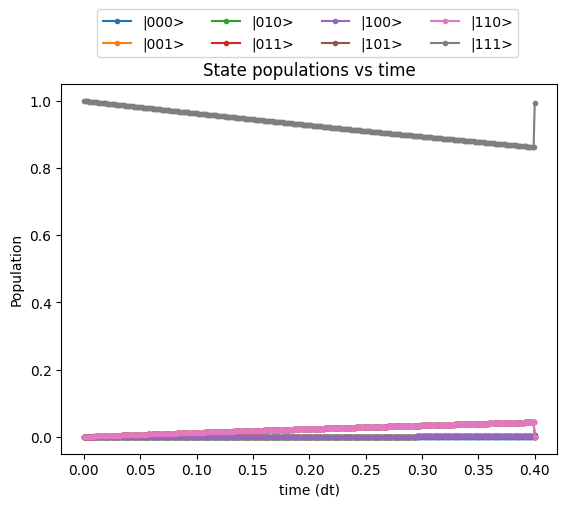

In [13]:
time = np.linspace(0, total_time, len(states))
time = np.linspace(0, total_time, len(plotting_states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    # for j in range(len(states)):
    for j in range(len(plotting_states)):
        data.append(np.real(qt.ptrace(plotting_states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")

In [14]:
# note to self for the sake of the ideal simulation the hadamards do not need to be absorbed into the gate but this brings out an interesting feature of the hadamards for the non-ideal case 